# Aula 2 — Um primeiro modelo de Machine Learning

## Exemplo muito simples: horas de estudo e nota

Imagine que desejamos responder:

> **A partir das horas de estudo, qual nota o modelo estima para um estudante?**

Este exemplo serve apenas para visualizar o caminho:

**dados → qualidade → treino/teste → treinamento → avaliação → previsão**


## 1. Importando as bibliotecas

- **Pandas:** organiza a pequena tabela;
- **Scikit-learn:** divide os dados, treina e avalia o modelo;
- **Matplotlib:** mostra os dados e a reta aprendida.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


## 2. Nossa pequena base de dados

- `horas_estudo` será a **variável preditora**;
- `nota` será a **variável-alvo** que desejamos prever.


In [3]:
dados = pd.DataFrame({
    "horas_estudo": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "nota": [2.5, 3.1, 4.0, 4.5, 5.2, 6.0, 6.8, 7.3, 8.1, 9.0],
})

dados


,horas_estudo,nota
0,1,2.5
1,2,3.1
2,3,4.0
3,4,4.5
4,5,5.2
5,6,6.0
6,7,6.8
7,8,7.3
8,9,8.1
9,10,9.0


## 3. Uma verificação mínima de qualidade

Antes de treinar, verificamos se existem valores ausentes ou linhas duplicadas.


In [4]:
print("Valores ausentes:")
print(dados.isna().sum())

print("\nLinhas duplicadas:", dados.duplicated().sum())


Valores ausentes:
horas_estudo    0
nota            0
dtype: int64

Linhas duplicadas: 0


## 4. Separando variável preditora e alvo

Por convenção, usamos:

- `X` para os dados usados na previsão;
- `y` para a resposta que o modelo deve aprender.


In [5]:
X = dados[["horas_estudo"]]
y = dados["nota"]

print("X — variável preditora")
display(X.head())

print("y — variável-alvo")
display(y.head())


X — variável preditora


,horas_estudo
0,1
1,2
2,3
3,4
4,5


y — variável-alvo


,nota
0,2.5
1,3.1
2,4.0
3,4.5
4,5.2


## 5. Dividindo em treino e teste

Usaremos **70% para treino** e **30% para teste**.

O modelo aprende apenas com o treino. O teste simula dados que ele ainda não viu.


In [7]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)

print("Exemplos de treino:", len(X_treino))
print("Exemplos de teste:", len(X_teste))


Exemplos de treino: 7
Exemplos de teste: 3


## 6. Treinando o modelo

Como queremos estimar um valor numérico — a nota — este é um exemplo de **regressão**.


In [8]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print("Modelo treinado!")


Modelo treinado!


## 7. Testando e avaliando

O erro absoluto médio mostra, em média, quantos pontos separam a previsão da nota real.


In [9]:
previsoes_teste = modelo.predict(X_teste)
erro = mean_absolute_error(y_teste, previsoes_teste)

comparacao = pd.DataFrame({
    "nota_real": y_teste,
    "nota_prevista": previsoes_teste.round(2),
})

display(comparacao)
print("Erro absoluto médio:", round(erro, 2))


,nota_real,nota_prevista
8,8.1,8.16
1,3.1,3.17
5,6.0,6.02


Erro absoluto médio: 0.05


## 8. Fazendo uma nova previsão

Agora fornecemos um dado novo: **6,5 horas de estudo**.


In [10]:
novo_dado = pd.DataFrame({"horas_estudo": [6.5]})
nota_prevista = modelo.predict(novo_dado)[0]

print("Nota prevista para 6,5 horas de estudo:", round(nota_prevista, 2))


Nota prevista para 6,5 horas de estudo: 6.38


## 9. Visualizando a ideia

Os pontos representam os dados. A linha representa o padrão aprendido pelo modelo.


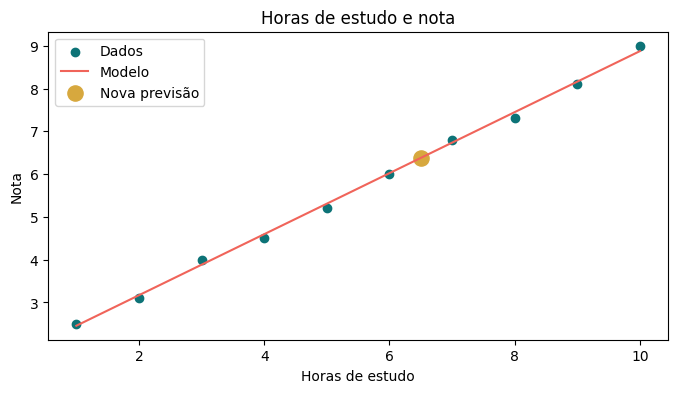

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(dados["horas_estudo"], dados["nota"], color="#0D7377", label="Dados")
plt.plot(dados["horas_estudo"], modelo.predict(dados[["horas_estudo"]]), color="#F0645A", label="Modelo")
plt.scatter(6.5, nota_prevista, color="#D7A83E", s=120, label="Nova previsão")

plt.title("Horas de estudo e nota")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota")
plt.legend()
plt.show()


## O que aconteceu?

1. Criamos uma base estruturada.
2. Verificamos aspectos básicos de qualidade.
3. Identificamos a variável preditora e a variável-alvo.
4. Dividimos os dados em treino e teste.
5. Treinamos um modelo de regressão.
6. Avaliamos o erro em dados não vistos.
7. Fizemos uma previsão para um caso novo.

> Este exemplo é propositalmente pequeno e didático. Dez registros não seriam suficientes para construir um modelo real confiável.
